[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JaimeHuaytallaPariona/ingenieria-conocimiento-uncp/blob/master/recursos/sesion_01_ciclo_vida_ml.ipynb)

# Sesión 01 — Ciclo de Vida de Proyectos de Machine Learning
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  

---

## Objetivo
Recorrer el ciclo de vida completo de un proyecto de Machine Learning — desde la recolección de datos hasta la evaluación y serialización del modelo — utilizando el dataset **Heart Disease** de UCI y las herramientas del ecosistema Scikit-learn.

## 1. Configuración del entorno
Instalamos/importamos las librerías necesarias. En Google Colab la mayoría ya están disponibles.

In [8]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import joblib

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Etapa 1 — Recolección de datos
Cargamos el **Loan Prediction dataset** (Dream Housing Finance) desde un repositorio público. Este dataset se usa para predecir si a un solicitante se le aprobará o no un préstamo, según sus datos personales y financieros.

| Variable | Descripción |
|---|---|
| `Loan_ID` | Identificador único del préstamo (se descarta, no aporta información predictiva) |
| `Gender` | Género del solicitante (Male/Female) |
| `Married` | Estado civil (Y/N) |
| `Dependents` | Número de dependientes (0, 1, 2, 3+) |
| `Education` | Nivel educativo (Graduate/Not Graduate) |
| `Self_Employed` | Trabajador independiente (Y/N) |
| `ApplicantIncome` | Ingreso del solicitante |
| `CoapplicantIncome` | Ingreso del co-solicitante |
| `LoanAmount` | Monto del préstamo (en miles) |
| `Loan_Amount_Term` | Plazo del préstamo (en meses) |
| `Credit_History` | Historial crediticio cumple con las políticas (1 = sí, 0 = no) |
| `Property_Area` | Zona de la propiedad (Urban/Semiurban/Rural) |
| `Loan_Status` | **Target** — préstamo aprobado (Y = sí, N = no) |

In [9]:
URL = 'https://raw.githubusercontent.com/dsrscientist/DSData/master/loan_prediction.csv'

# Intentamos cargar desde la URL; si falla, generamos un dataset sintético
# con la misma estructura, para que el notebook nunca se quede sin datos.
try:
    df = pd.read_csv(URL)
    print(f'Dataset cargado desde URL — {df.shape[0]} registros, {df.shape[1]} columnas')
except Exception as e:
    print(f'Error al cargar desde URL: {e}')
    print('Generando dataset sintético de respaldo con la misma estructura...')

    rng = np.random.default_rng(42)
    n = 600
    df = pd.DataFrame({
        'Loan_ID': [f'LP{100000+i}' for i in range(n)],
        'Gender': rng.choice(['Male', 'Female'], size=n, p=[0.8, 0.2]),
        'Married': rng.choice(['Yes', 'No'], size=n, p=[0.65, 0.35]),
        'Dependents': rng.choice(['0', '1', '2', '3+'], size=n, p=[0.55, 0.18, 0.18, 0.09]),
        'Education': rng.choice(['Graduate', 'Not Graduate'], size=n, p=[0.78, 0.22]),
        'Self_Employed': rng.choice(['No', 'Yes'], size=n, p=[0.85, 0.15]),
        'ApplicantIncome': rng.integers(1500, 20000, size=n),
        'CoapplicantIncome': rng.integers(0, 8000, size=n),
        'LoanAmount': rng.integers(20, 400, size=n).astype(float),
        'Loan_Amount_Term': rng.choice([360, 180, 120, 300, 240], size=n),
        'Credit_History': rng.choice([1.0, 0.0], size=n, p=[0.85, 0.15]),
        'Property_Area': rng.choice(['Urban', 'Semiurban', 'Rural'], size=n),
    })
    approval_prob = (
        0.3
        + 0.3 * df['Credit_History']
        + 0.1 * (df['Education'] == 'Graduate')
        + 0.1 * (df['ApplicantIncome'] > df['ApplicantIncome'].median())
    ).clip(0.05, 0.95)
    df['Loan_Status'] = np.where(rng.random(n) < approval_prob, 'Y', 'N')

    # Insertamos algunos nulos, igual que en el dataset original
    for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']:
        mask = rng.random(n) < 0.04
        df.loc[mask, col] = np.nan

    print(f'Dataset sintético generado — {df.shape[0]} registros, {df.shape[1]} columnas')

df.head()

Error al cargar desde URL: <urlopen error [Errno 11001] getaddrinfo failed>
Generando dataset sintético de respaldo con la misma estructura...
Dataset sintético generado — 600 registros, 13 columnas


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP100000,Male,Yes,1,Graduate,No,12955,1084,278.0,120.0,1.0,Semiurban,Y
1,LP100001,Male,No,1,Graduate,No,16840,7540,128.0,360.0,1.0,Semiurban,Y
2,LP100002,Female,No,2,Graduate,No,13343,3800,120.0,300.0,1.0,Urban,Y
3,LP100003,Male,No,1,Graduate,Yes,12490,2553,69.0,240.0,1.0,Urban,Y
4,LP100004,Male,No,0,Graduate,No,10146,3568,21.0,300.0,NaN,Semiurban,N


---
## 3. Etapa 2 — Exploración y preparación de datos

In [10]:
# 3.1  Información general del dataset
print('='*60)
print('INFORMACIÓN DEL DATASET')
print('='*60)
df.info()
print('\n')
df.describe().round(2)

INFORMACIÓN DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            600 non-null    str    
 1   Gender             573 non-null    str    
 2   Married            577 non-null    str    
 3   Dependents         573 non-null    str    
 4   Education          600 non-null    str    
 5   Self_Employed      577 non-null    str    
 6   ApplicantIncome    600 non-null    int64  
 7   CoapplicantIncome  600 non-null    int64  
 8   LoanAmount         576 non-null    float64
 9   Loan_Amount_Term   571 non-null    float64
 10  Credit_History     573 non-null    float64
 11  Property_Area      600 non-null    str    
 12  Loan_Status        600 non-null    str    
dtypes: float64(3), int64(2), str(8)
memory usage: 61.1 KB




,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,600.00,600.00,576.00,571.00,573.00
mean,10054.46,4043.56,206.52,237.48,0.86
std,5369.29,2301.82,107.41,87.67,0.35
min,1515.00,5.00,20.00,120.00,0.00
25%,5113.25,2249.50,114.00,180.00,1.00
50%,9870.00,4049.00,205.50,240.00,1.00
75%,14635.50,6072.50,297.00,300.00,1.00
max,19955.00,7995.00,399.00,360.00,1.00


In [11]:
# 3.2  Verificación de valores nulos y duplicados
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nRegistros duplicados: {df.duplicated().sum()}')


Valores nulos por columna:
Loan_ID               0
Gender               27
Married              23
Dependents           27
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           24
Loan_Amount_Term     29
Credit_History       27
Property_Area         0
Loan_Status           0
dtype: int64

Registros duplicados: 0


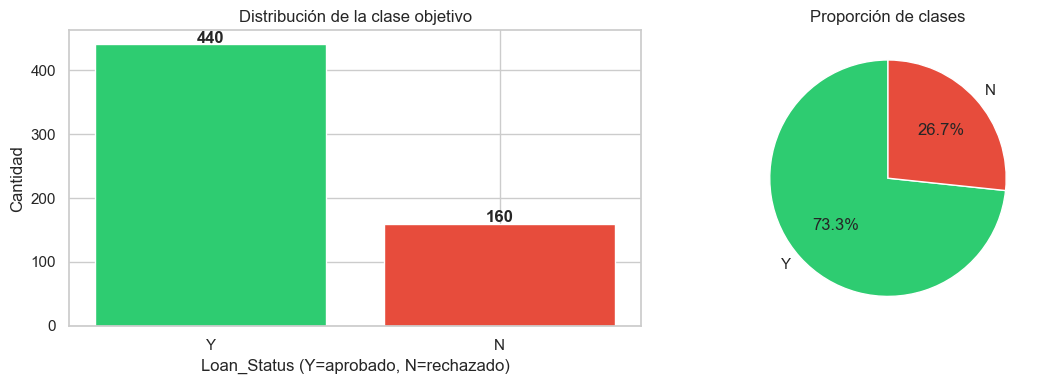

In [12]:
# 3.3  Distribución de la variable objetivo (Loan_Status)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['Loan_Status'].value_counts()
axes[0].bar(target_counts.index.astype(str), target_counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución de la clase objetivo')
axes[0].set_xlabel('Loan_Status (Y=aprobado, N=rechazado)')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=target_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

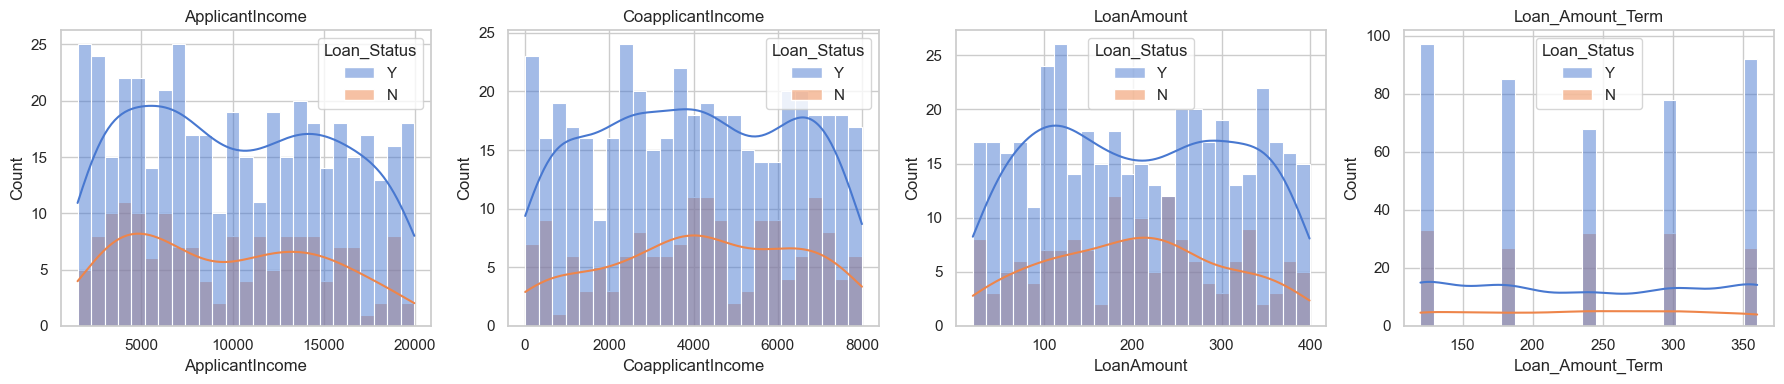

In [13]:
# 3.4  Distribución de variables numéricas clave
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='Loan_Status', kde=True, ax=ax, bins=25)
    ax.set_title(col)
plt.tight_layout()
plt.show()

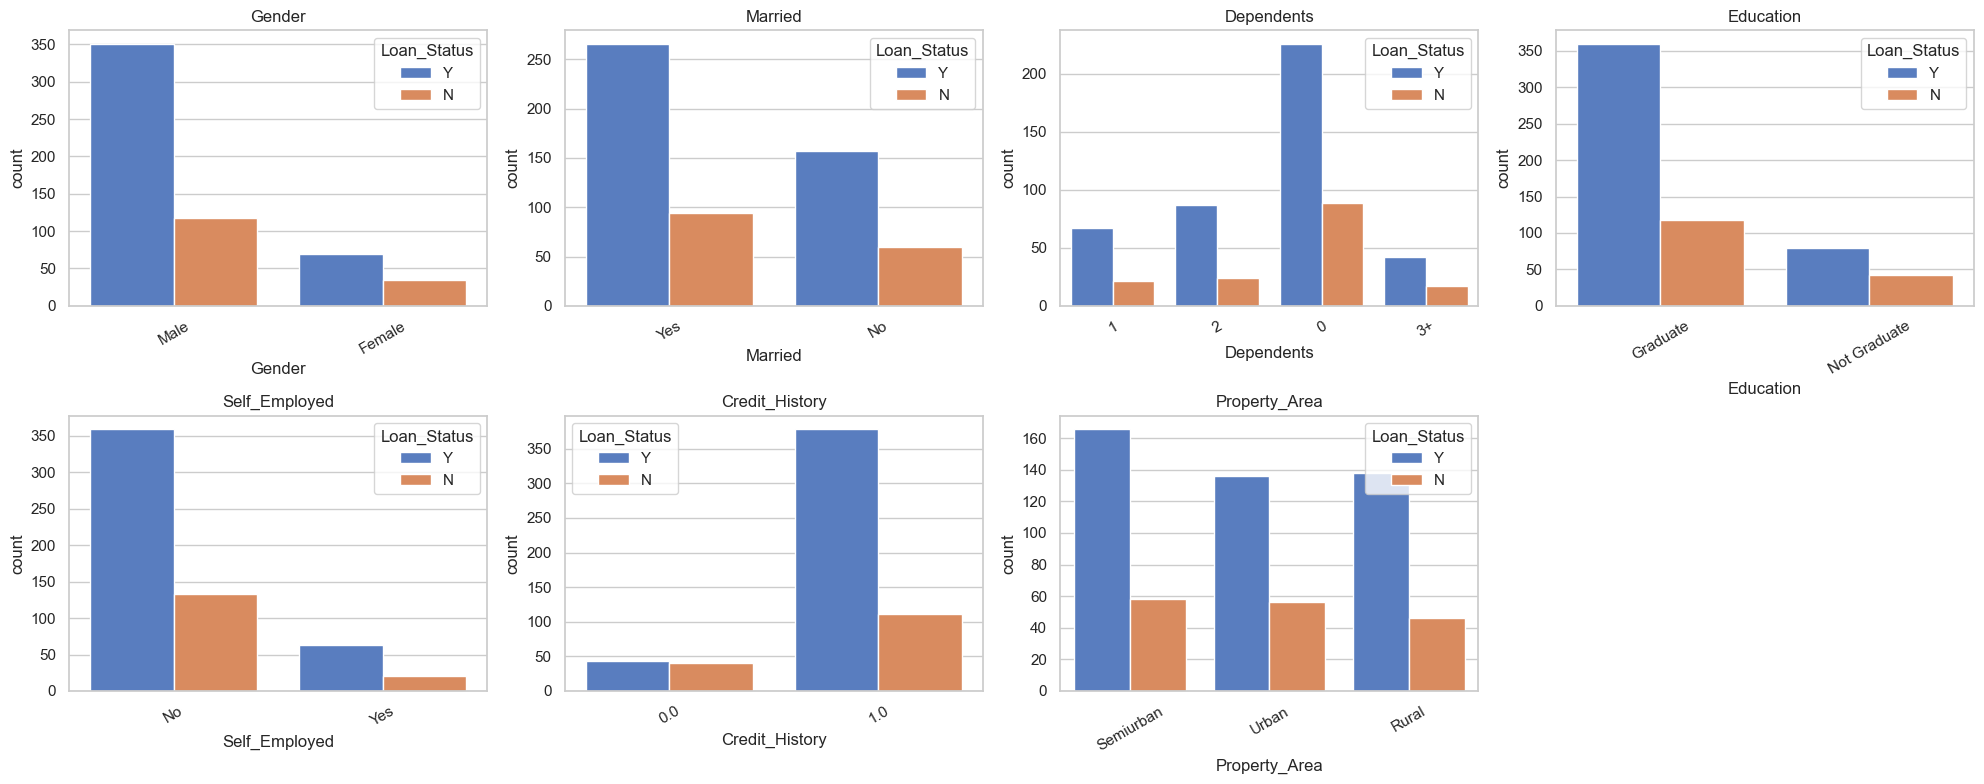

In [14]:
# 3.5  Variables categóricas vs. aprobación del préstamo
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, hue='Loan_Status', ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# 3.6 Matriz de correlación (solo variables numéricas)
plt.figure(figsize=(8, 6))

corr = df[num_cols + ['Credit_History']].corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5
)

plt.title('Matriz de correlación — Loan Prediction Dataset')
plt.tight_layout()
plt.show()

---
## 4. Etapa 3 — Preparación de datos para el modelado

In [ ]:
# 4.1  Separación de features y target
X = df.drop(columns='target')
y = df['target']

print(f'Features: {X.shape}')   # (n_samples, n_features)
print(f'Target:   {y.shape}')   # (n_samples,)

Features: (270, 13)
Target:   (270,)


In [ ]:
# 4.2  División train / test (80-20, estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras')
print(f'Test:  {X_test.shape[0]} muestras')
print(f'\nProporción target en train:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'\nProporción target en test:\n{y_test.value_counts(normalize=True).round(3)}')

Train: 216 muestras
Test:  54 muestras

Proporción target en train:
target
-1.0    0.556
 1.0    0.444
Name: proportion, dtype: float64

Proporción target en test:
target
-1.0    0.556
 1.0    0.444
Name: proportion, dtype: float64


---
## 5. Etapa 4 — Entrenamiento de modelos
Entrenamos tres modelos base mediante **pipelines** de Scikit-learn para garantizar un flujo reproducible.

In [ ]:
# 5.1  Definición de pipelines
pipelines = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'DecisionTree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42))
    ])
}

# 5.2  Entrenamiento y validación cruzada (5-fold)
results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:25s}  Accuracy CV: {scores.mean():.4f} ± {scores.std():.4f}')

LogisticRegression         Accuracy CV: 0.8288 ± 0.0682
DecisionTree               Accuracy CV: 0.7637 ± 0.0350
RandomForest               Accuracy CV: 0.8148 ± 0.0390


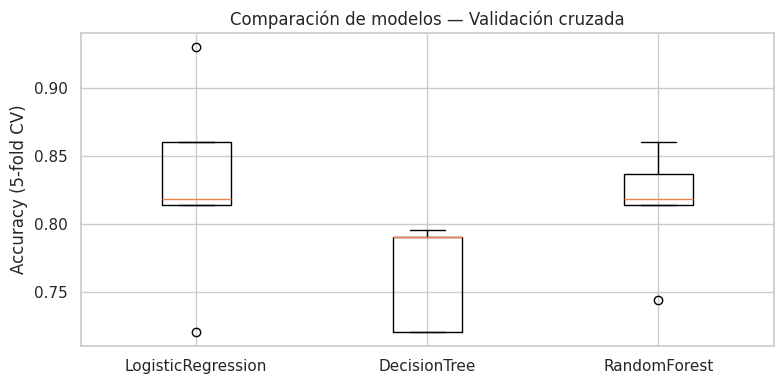

In [ ]:
# 5.3  Comparación visual de modelos
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(results.values(), tick_labels=results.keys())
ax.set_ylabel('Accuracy (5-fold CV)')
ax.set_title('Comparación de modelos — Validación cruzada')
plt.tight_layout()
plt.show()

---
## 6. Etapa 5 — Evaluación del mejor modelo

In [ ]:
# 6.1  Seleccionar el mejor modelo según CV y entrenar con todo el train set
best_name = max(results, key=lambda k: results[k].mean())
best_pipeline = pipelines[best_name]
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)

print(f'Mejor modelo: {best_name}')
print(f'Accuracy en test: {best_pipeline.score(X_test, y_test):.4f}')
print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, y_pred, target_names=['Sano', 'Enfermedad']))

Mejor modelo: LogisticRegression
Accuracy en test: 0.8519

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Sano       0.92      0.80      0.86        30
  Enfermedad       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54



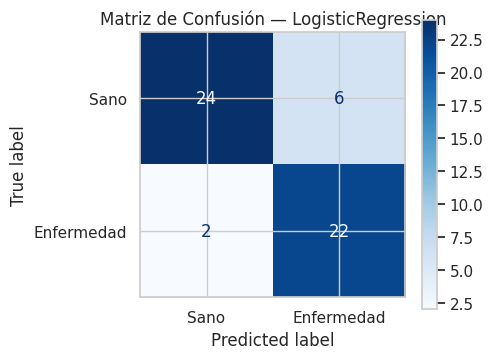

In [ ]:
# 6.2  Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Sano', 'Enfermedad'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusión — {best_name}')
plt.tight_layout()
plt.show()

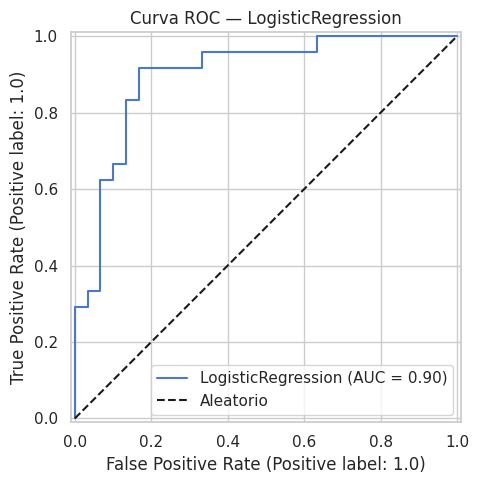

In [ ]:
# 6.3  Curva ROC (solo si el modelo soporta predict_proba)
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=ax, name=best_name)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
ax.set_title(f'Curva ROC — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Etapa 6 — Serialización y despliegue conceptual
Guardamos el pipeline entrenado con `joblib` para simular la etapa de despliegue.

In [ ]:
# 7.1  Guardar el modelo
MODEL_PATH = 'heart_disease_model.joblib'
joblib.dump(best_pipeline, MODEL_PATH)
print(f'Modelo guardado en: {MODEL_PATH}')

Modelo guardado en: heart_disease_model.joblib


In [ ]:
# 7.2  Cargar y verificar el modelo serializado
loaded_model = joblib.load(MODEL_PATH)

# Verificación rápida: misma predicción con datos de test
assert np.array_equal(loaded_model.predict(X_test), y_pred), 'Error: predicciones no coinciden'
print('Verificación OK: el modelo cargado reproduce las predicciones.')

Verificación OK: el modelo cargado reproduce las predicciones.


In [ ]:
# 7.3  Función de inferencia (simula un endpoint de predicción)

def predict_heart_disease(patient_data: dict) -> dict:
    """
    Recibe un diccionario con los features del paciente
    y retorna la predicción y la probabilidad.
    """
    model = joblib.load(MODEL_PATH)

    # Mapeo de nombres originales a nombres genéricos de OpenML
    feature_name_map = {
        'age': 'att_1',
        'sex': 'att_2',
        'cp': 'att_3',
        'trestbps': 'att_4',
        'chol': 'att_5',
        'fbs': 'att_6',
        'restecg': 'att_7',
        'thalach': 'att_8',
        'exang': 'att_9',
        'oldpeak': 'att_10',
        'slope': 'att_11',
        'ca': 'att_12',
        'thal': 'att_13'
    }

    # Renombrar las claves en patient_data y asegurar el orden correcto de las columnas
    # 'feature_names' es una variable global del kernel que contiene el orden correcto de las columnas
    # (e.g., ['att_1', 'att_2', ..., 'att_13'])
    try:
        renamed_patient_data_ordered = {feature_name_map[k]: patient_data[k] for k in feature_name_map.keys()}
        ordered_values = [renamed_patient_data_ordered[name] for name in feature_names]
        input_df = pd.DataFrame([ordered_values], columns=feature_names)
    except KeyError as e:
        raise ValueError(f"Missing or incorrect feature name in patient_data: {e}. Expected descriptive names from the mapping.")

    pred = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0]

    # Ajustar etiquetas de predicción según las clases del modelo (-1.0 y 1.0)
    prediction_label = 'Enfermedad cardíaca' if pred == 1.0 else 'Sano'

    # Asumiendo que proba[0] es para la clase -1.0 (Sano) y proba[1] para 1.0 (Enfermedad)
    return {
        'prediccion': prediction_label,
        'probabilidad_enfermedad': round(float(proba[1]), 4),
        'probabilidad_sano': round(float(proba[0]), 4)
    }

# Ejemplo de uso con un paciente ficticio
paciente_ejemplo = {
    'age': 55, 'sex': 1, 'cp': 2, 'trestbps': 140,
    'chol': 250, 'fbs': 0, 'restecg': 1, 'thalach': 150,
    'exang': 0, 'oldpeak': 1.5, 'slope': 1, 'ca': 0, 'thal': 2
}

resultado = predict_heart_disease(paciente_ejemplo)
print('\n--- Resultado de inferencia ---')
for k, v in resultado.items():
    print(f'  {k}: {v}')


--- Resultado de inferencia ---
  prediccion: Enfermedad cardíaca
  probabilidad_enfermedad: 1.0
  probabilidad_sano: 0.0


---
## 8. Resumen del ciclo de vida recorrido

| Etapa | Qué hicimos | Herramientas |
|---|---|---|
| **Recolección** | Descarga del dataset Heart Disease (UCI/OpenML) | `pandas`, URL pública |
| **Exploración** | Análisis de distribuciones, correlaciones, nulos | `seaborn`, `matplotlib` |
| **Preparación** | Limpieza, split estratificado 80/20 | `train_test_split` |
| **Entrenamiento** | 3 modelos con pipelines + validación cruzada 5-fold | `Pipeline`, `cross_val_score` |
| **Evaluación** | Accuracy, precision, recall, F1, ROC, matriz confusión | `classification_report`, `RocCurveDisplay` |
| **Despliegue** | Serialización con joblib + función de inferencia | `joblib` |

---
## 9. Ejercicios propuestos

### Ejercicio 1 — Experimentación con hiperparámetros
Utilice `GridSearchCV` o `RandomizedSearchCV` para optimizar los hiperparámetros del `RandomForestClassifier`. Compare el accuracy antes y después del tuning.

### Ejercicio 2 — Nuevo dataset, mismo pipeline
Descargue el dataset **Diabetes** de Scikit-learn (`sklearn.datasets.load_diabetes`) o el **Breast Cancer Wisconsin** (`sklearn.datasets.load_breast_cancer`) y replique el ciclo de vida completo aplicado en esta sesión.

### Ejercicio 3 — Registro de experimentos
Investigue la librería **MLflow** (`!pip install mlflow`) e implemente un registro básico de las métricas y parámetros de cada modelo entrenado. Documente los pasos realizados.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*